# Defining mode sources and monitors

Here, we look at a simple demonstration of how to excite a specific waveguide mode, and how to decompose the fields recorded in a monitor on the basis of waveguide modes, i.e. how to compute the power carried in each mode.

We also provide a conprehensive list of other tutorials such as [how to define boundary conditions](https://www.flexcompute.com/tidy3d/examples/notebooks/BoundaryConditions/), [how to defining spatially-varying sources](https://www.flexcompute.com/tidy3d/examples/notebooks/CustomFieldSource/) and [structures](https://www.flexcompute.com/tidy3d/examples/notebooks/CustomMediumTutorial/), [how to model dispersive materials](https://www.flexcompute.com/tidy3d/examples/notebooks/Dispersion/), and [how to visualize simulation setups](https://www.flexcompute.com/tidy3d/examples/notebooks/VizSimulation/) and [results](https://www.flexcompute.com/tidy3d/examples/notebooks/VizData/).

If you are new to the finite-difference time-domain (FDTD) method, we highly recommend going through our [FDTD101](https://www.flexcompute.com/fdtd101/) tutorials. 

In [1]:
# standard python imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# tidy3D import
import tidy3d as td
from tidy3d import web
from tidy3d.plugins.mode import ModeSolver


### Straight waveguide simulation

First, we will do a simulation of a straight waveguide, using a silicon ridge waveguide on a silicon oxide substrate. We begin by defining some general parameters.

In [2]:
# Unit length is micron.
wg_height = 0.22
wg_width = 0.45

# Permittivity of waveguide and substrate
si_eps = 3.48**2
sio_eps = 1.45**2

# Free-space wavelength (in um) and frequency (in Hz)
lambda0 = 1.55
freq0 = td.C_0 / lambda0
fwidth = freq0 / 10

# Simulation size inside the PML along propagation direction
sim_length = 5

# Simulation domain size and total run time
sim_size = [sim_length, 4, 2]
run_time = 20 / fwidth

# Grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=lambda0)


### Initialize structures, mode source, and mode monitor

When initializing `ModeSource` and `ModeMonitor` objects, one of the three values of the `size` parameter must be zero. This implicitly defines the propagation direction for the mode decomposition. In this example, the waveguide is oriented along the x-axis, and the mode is injected along the positive-x direction ("forward"). Below, we add a mode monitor that will show us the waveguide transmission at a range of frequencies, as well as a simple frequency monitor to examine the fields in the xy-plane at the central frequency. Note that we use a rather wide frequency range in the flux and modal monitors. This will be used later to demonstrate the effect of mode mismatch away from the central frequency and to discuss ways to remedy that.

In [3]:
# Waveguide and substrate materials
mat_wg = td.Medium(permittivity=si_eps)
mat_sub = td.Medium(permittivity=sio_eps)

# Substrate
substrate = td.Structure(
    geometry=td.Box(
        center=[0, 0, -sim_size[2]],
        size=[td.inf, td.inf, 2 * sim_size[2]],
    ),
    medium=mat_sub,
)

# Waveguide
waveguide = td.Structure(
    geometry=td.Box(
        center=[0, 0, wg_height / 2],
        size=[100, wg_width, wg_height],
    ),
    medium=mat_wg,
)

# Modal source parameters
src_pos = -sim_size[0] / 2 + 0.5
src_plane = td.Box(center=[src_pos, 0, 0], size=[0, 3, 2])

# xy-plane frequency-domain field monitor at central frequency
freq_mnt = td.FieldMonitor(
    center=[0, 0, wg_height / 2], size=[100, 100, 0], freqs=[freq0], name="field"
)


# frequencies
mon_plane = td.Box(center=[-src_pos, 0, 0], size=[0, 3, 2])
Nfreqs = 17
freqs = np.linspace(freq0 - 2 * fwidth, freq0 + 2 * fwidth, Nfreqs)
fcent_ind = Nfreqs // 2  # index of the central frequency

# flux monitor
flux_mnt = td.FluxMonitor(
    center=mon_plane.center, size=mon_plane.size, freqs=list(freqs), name="flux"
)

# Modal monitor at a range of frequencies
mode_mnt = td.ModeMonitor(
    center=mon_plane.center,
    size=mon_plane.size,
    freqs=list(freqs),
    mode_spec=td.ModeSpec(num_modes=3),
    name="mode",
)


Initialize simulation and visualize two cross-sections to make sure we have set up the device correctly.

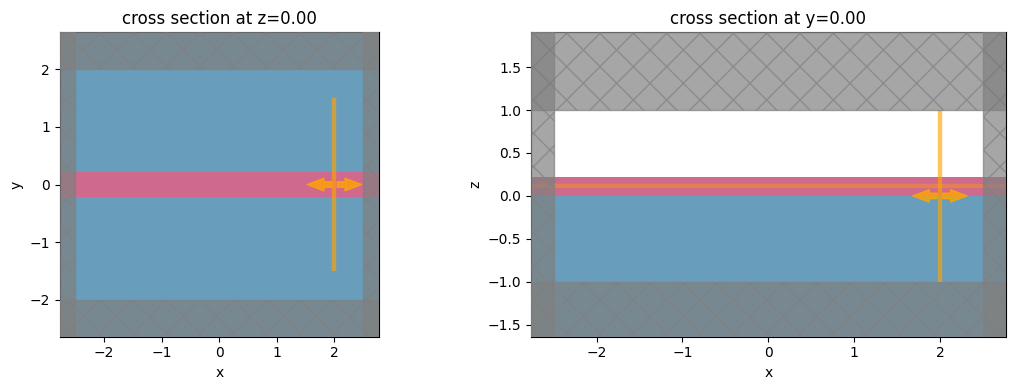

In [4]:
# Simulation
sim = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=[substrate, waveguide],
    sources=[],
    monitors=[freq_mnt, mode_mnt, flux_mnt],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(11, 4))
sim.plot(z=0, ax=ax1)
sim.plot(y=0, ax=ax2)
plt.show()


Note that Tidy3D is warning us that the simulation does not contain a source. However, since this simulation is used to construct the mode solver and will not be run directly, we can ignore this warning.

### Mode source

Before we can run a simulation with a mode source, we have to select which of the eigenmodes we would like to inject. To do that, we can first visualize the modes using the in-built eigenmode solver and plotting functions. The modes are computed at the central frequency of the source, and in order of decreasing effective index `n`, such that the modes that are fully below light-line (if any) should appear first. The solver assumes periodic boundary conditions at the boundaries of the 2D plane. Thus, for accurate results, the plane should be large enough for the fields to decay at the edges. In cases when found solutions do not decay to zero at the plane boundaries a warning is shown to make the user aware.

04:38:35 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.plugins.mode.web.run(...)'.        

04:38:36 PDT WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
1.934145e+14 0                 1.55  2.330604    0.0          0.979003   
             1                 1.55  1.545622    0.0          0.068648   
             2                 1.55  1.370215    0.0          0.012079   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.934145e+14 0                 0.708738        0.817743   0.186907  
             1                 0.733944        0.882324   0.407554  
             2                 0.842603        0.936078   1.784773

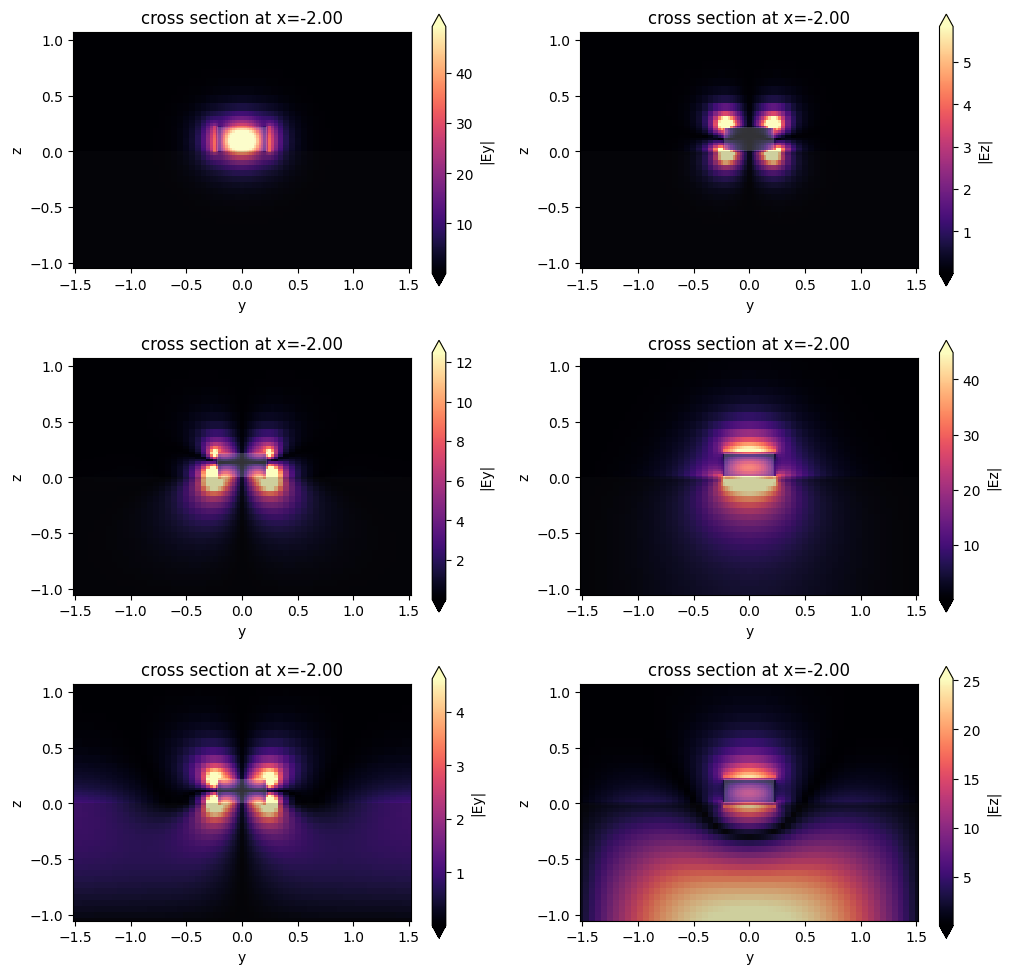

In [5]:
# Visualize the modes
mode_spec = td.ModeSpec(num_modes=3)
ms = ModeSolver(simulation=sim, plane=src_plane, mode_spec=mode_spec, freqs=[freq0])
modes = ms.solve()

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for mode_ind in range(3):
    ms.plot_field("Ey", "abs", f=freq0, mode_index=mode_ind, ax=axs[mode_ind, 0])
    ms.plot_field("Ez", "abs", f=freq0, mode_index=mode_ind, ax=axs[mode_ind, 1])

modes.to_dataframe()

The waveguide has a single guided TE mode, as well as a TM mode which is very close to the light line (effective index close to substrate index). Finally, the last mode shown here, is below the light-line of the substrate and is mostly localized in that region. However, modes like these should always be considered unphysical, because of the assumption is that they decay by the edges of the mode plane. Thus, for meaningful results, only Mode 0 and Mode 1 should be used by the mode source.

### Run simulation

We set the mode source to the fundamental TE mode. Then, we run the simulation as usual through the web API, wait for it to finish, and download and load the results.

In [6]:
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)
mode_source = ms.to_source(mode_index=0, direction="+", source_time=source_time)
sim = sim.copy(update=dict(sources=[mode_source]))


As of tidy3d 2.4 there is an alternative way to export a simulation with the mode source added through the `sim_with_source()` method, which creates a simulation in the mode solver, using the same inputs as `to_source()` above, with the created mode source, as done below. There are also `sim_with_monitor()` and `sim_with_mode_solver_monitor()` methods that return simulations with the corresponding objects added.

In [7]:
sim = ms.sim_with_source(mode_index=0, direction="+", source_time=source_time)

In [8]:
job = web.Job(simulation=sim, task_name="mode_tutorial", verbose=True)
sim_data = job.run(path="data/simulation.hdf5")


04:38:38 PDT Created task 'mode_tutorial' with task_id                          
             'fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=85182;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=145686;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\taskId]8;;\]8;id=85182;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\=]8;;\]8;id=927913;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\fdve]8;;\]8;id=85182;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\-2cd91acc-6e7]8;;\
             ]8;id=85182;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\b-409e-8e57-32664cd105d6']8;;\.

Output()

04:38:39 PDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

04:38:53 PDT status = success

             View simulation result at                                          
             ]8;id=804850;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=96353;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\taskId]8;;\]8;id=804850;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\=]8;;\]8;id=580370;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\fdve]8;;\]8;id=804850;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\-2cd91acc-6e7]8;;\
             ]8;id=804850;https://tidy3d.simulation.cloud/workbench?taskId=fdve-2cd91acc-6e7b-409e-8e57-32664cd105d6\b-409e-8e57-32664cd105d6']8;;\.

Output()

04:38:54 PDT loading simulation from data/simulation.hdf5

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

Let's first examine the in-plane fields recorded by the frequency monitor. We can already see how the source emits all of its power in the desired direction and waveguide mode.

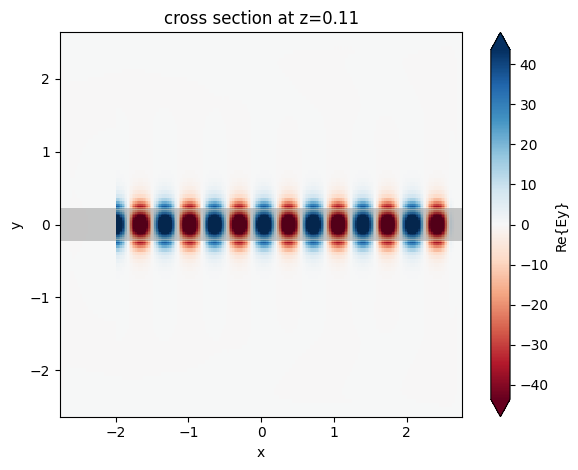

In [9]:
sim_data.plot_field("field", "Ey", z=wg_height / 2, f=freq0, val="real")
plt.show()


### Mode monitors

Mode monitors allow us to decompose the frequency-domain fields recorded in a simulation into the propagating modes of a waveguide. Specifically, we can write the modes of the waveguide at angular frequency $\omega$ that are propagating in the *forward* direction, i.e. in the positive `x` direction in the example above, as

$$
\mathbf{E}_p^f(\omega, x) = \mathbf{E}_p^f(\omega) e^{i k_p x}, \quad \quad \mathbf{H}_p^f(\omega, x) = \mathbf{H}_p^f(\omega) e^{i k_p x},
$$

where $p$ is a discrete mode index, $k_p = n_p \omega/c$ is the wave-vector, $n_p$ is the effective index of the $p$-th mode, and superscript $f$ specifies forward propagation. The fields in the backward direction can be obtained via reflection symmetry. In the axes of the simulation we have $k_p \rightarrow -k_p$ and $\mathbf{E}_{p}^b(\omega) = (-E_{p,x}^{f}, E_{p,y}^{f}, E_{p,z}^{f})$, $\mathbf{H}_{p}^b(\omega) = (H_{p,x}^{f}, -H_{p,y}^{f}, -H_{p,z}^{f})$ for backward modes.

The fields stored in a monitor can then be decomposed on the basis of these waveguide modes. Following [1](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.66.066608), [2](https://arxiv.org/abs/1301.5366), we can define an inner product between fields in the 2D plane as

$$
(\mathbf{u}_1, \mathbf{u}_2) = \frac{1}{4} \int_A \left(\mathbf{E}_1^* \times \mathbf{H}_2 + \mathbf{E}_2 \times \mathbf{H}_1^* \right) \cdot \mathrm{d}\mathbf{A},
$$

where $\mathbf{u} = (\mathbf{E}, \mathbf{H})$ combines both electromagnetic fields, the integration is over the plane area $A$, and $\mathrm{d}\mathbf{A}$ is the surface normal. From this definition it is clear that $(\mathbf{u}_p, \mathbf{u}_p)$ is just the flux carried by a mode $\mathbf{u}_p$, which is positive for forward-propagating modes and negative for backward-propagating ones. Note that the modes coming from the mode solver are normalized to unit directed flux, such that $(\mathbf{u}_p, \mathbf{u}_p) = \pm 1$. The mode monitor amplitudes are defined by the complex coefficient

$$
c_p = \frac{(\mathbf{u}_p, \mathbf{u}_s)}{(\mathbf{u}_p, \mathbf{u}_p)}
$$

which is the power amplitude of field $\mathbf{u}_s$ carried by mode $p$, while the power carried by that mode is given by $|c_p|^2$.

We can have a look at the monitor modes, but as expected they should be identical to the source modes. As previously, the unphysical mode that does not decay to zero at the plane boundary triggers a warning.

04:38:55 PDT WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

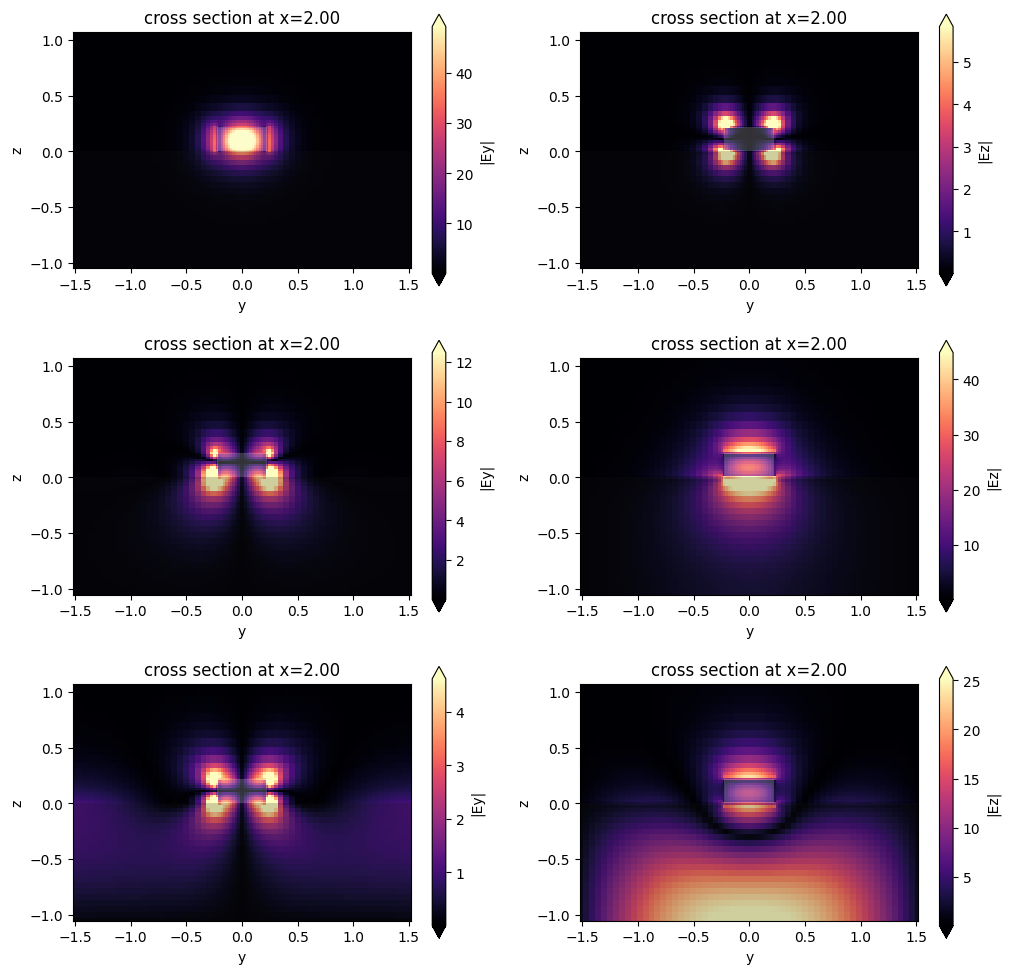

In [10]:
# Visualize the monitor modes
ms = ModeSolver(
    simulation=sim, plane=mode_mnt.geometry, mode_spec=mode_mnt.mode_spec, freqs=[freq0]
)
modes = ms.solve()

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for mode_ind in range(3):
    ms.plot_field("Ey", "abs", f=freq0, mode_index=mode_ind, ax=axs[mode_ind, 0])
    ms.plot_field("Ez", "abs", f=freq0, mode_index=mode_ind, ax=axs[mode_ind, 1])


We note that in ``Tidy3D``, the fields recorded by frequency monitors (and thus also mode monitors) are automatically normalized by the power amplitude spectrum of the source (for multiple sources, the user can select which source to use for the normalization). Furthermore, mode sources are normalized to inject exactly 1W of power at the central frequency.

In [11]:
# Flux in the mode monitor (total power through the cross-section)
flux_wg = sim_data["flux"].flux
print("Flux at central frequency: ", flux_wg.isel(f=fcent_ind).values)


Flux at central frequency:  0.9999903


We can also use the mode amplitudes recorded in the mode monitor to reveal the decomposition of the radiated power into forward- and backward-propagating modes, respectively. As we would expect, all of the power is injected into the fundamental waveguide mode, in the forward direction. More precisely, this is true up to some numerical error that decreases with increasing simulation resolution.

Power distribution at central frequency in first three modes
  positive dir.  [9.99990317e-01 5.19413815e-14 4.72197455e-14]
  negative dir.  [1.16694876e-09 2.65426222e-15 2.07663218e-15]


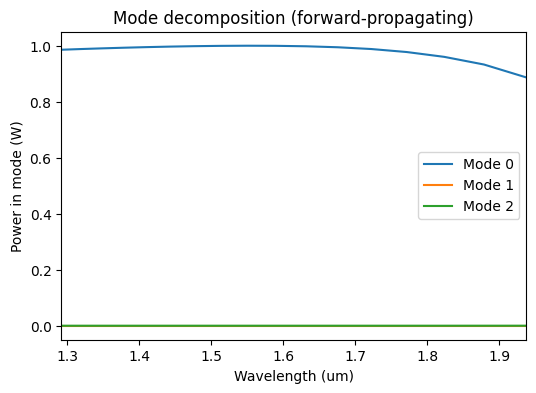

In [12]:
# Forward and backward power amplitude coefficients
mode_amps = sim_data["mode"]
coeffs_f = mode_amps.amps.sel(direction="+")
coeffs_b = mode_amps.amps.sel(direction="-")

print(
    "Power distribution at central frequency in first three modes",
)
print("  positive dir. ", np.abs(coeffs_f.isel(f=fcent_ind) ** 2).values)
print("  negative dir. ", np.abs(coeffs_b.isel(f=fcent_ind) ** 2).values)

# Free-space wavelength corresponding to the monitor frequencies
lambdas = td.C_0 / freqs

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas, np.abs(coeffs_f.values) ** 2)
ax.set_xlim([lambdas[-1], lambdas[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power in mode (W)")
ax.set_title("Mode decomposition (forward-propagating)")
ax.legend(["Mode 0", "Mode 1", "Mode 2"])
plt.show()


We can examine the frequency dependence of the results a bit more closely, and compare them to the total power flux, which can be computed for any frequency monitor. The flux is the area-integrated time-averaged Poynting vector and gives the (signed) total power flowing through the surface. The flux computation and the modal decomposition are done in separate monitors and in a completely different way, but because all the power is in the fundamental mode here, the flux matches really well the zero-mode power from the power decomposition.

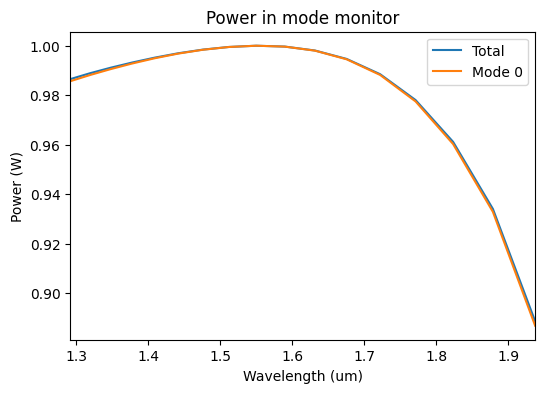

In [13]:
fig, ax = plt.subplots(1, figsize=(6, 4))

ax.plot(lambdas, flux_wg)
ax.plot(lambdas, np.abs(coeffs_f.sel(mode_index=0)) ** 2)
ax.set_xlim([lambdas[-1], lambdas[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power (W)")
ax.set_title("Power in mode monitor")
ax.legend(["Total", "Mode 0"])

plt.show()


As we already saw, at the central frequency, the source power is extremely well directed in the waveguide mode. Since the source mode is computed at the central frequency only, away from that it is not perfectly matched, leading to a small decrease of the total radiated power. In certain situations, it is even possible to observe injected power larger than one away from the central frequency. That said, we see that all the radiated power is still emitted into the desired waveguide mode, within the wavelength range of interest. For best accuracy when computing scattering parameters away from the central frequency, we can choose one of the following two options. The first option is to do a “normalization” run with a straight waveguide, like the one we just did, and normalize w.r.t. the computed flux to account for the small frequency dependence of the total radiated power. The other one is to use the Tidy3D's broadband source functionality, which takes into account the frequency dependence of injected fields. Both approaches are illustrated below.

### Waveguide junction (using normalization run)

We repeat the simulation, but this time introduce a much bigger waveguide in the second half of the domain.

In [14]:
# Output waveguide
wgout_width = 1.4

waveguide_out = td.Structure(
    geometry=td.Box(
        center=[2, 0, wg_height / 2],
        size=[4, wgout_width, wg_height],
    ),
    medium=mat_wg,
)


In [15]:
sim_jct = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    structures=[substrate, waveguide, waveguide_out],
    sources=[mode_source],
    monitors=[freq_mnt, mode_mnt, flux_mnt],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)


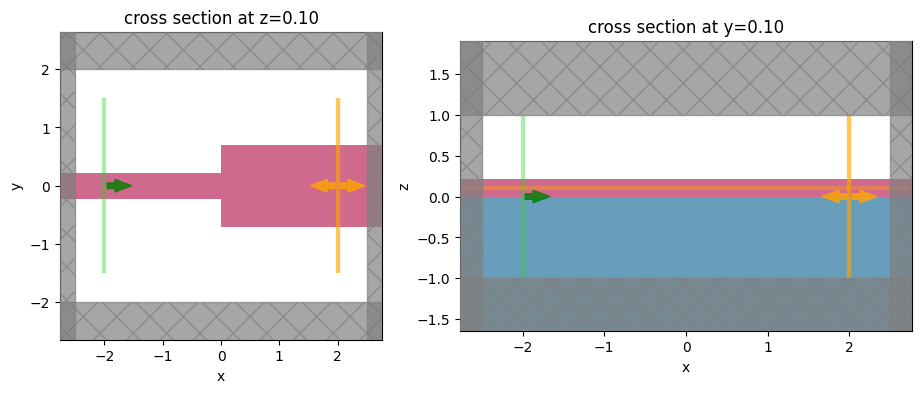

In [16]:
fig = plt.figure(figsize=(11, 4))
gs = mpl.gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.4])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
sim_jct.plot(z=0.1, ax=ax1)
sim_jct.plot(y=0.1, ax=ax2)
plt.show()


In [17]:
job = web.Job(simulation=sim_jct, task_name="mode_tutorial", verbose=True)
sim_data_jct = job.run(path="data/mode_converter.hdf5")


04:38:57 PDT Created task 'mode_tutorial' with task_id                          
             'fdve-40894efd-add8-444d-b86b-d0442ceea055' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=147414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=619358;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\taskId]8;;\]8;id=147414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\=]8;;\]8;id=587035;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\fdve]8;;\]8;id=147414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\-40894efd-add]8;;\
             ]8;id=147414;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\8-444d-b86b-d0442ceea055']8;;\.

Output()

04:38:58 PDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

Output()

             status = success

04:39:14 PDT View simulation result at                                          
             ]8;id=737554;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=572001;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\taskId]8;;\]8;id=737554;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\=]8;;\]8;id=668987;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\fdve]8;;\]8;id=737554;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\-40894efd-add]8;;\
             ]8;id=737554;https://tidy3d.simulation.cloud/workbench?taskId=fdve-40894efd-add8-444d-b86b-d0442ceea055\8-444d-b86b-d0442ceea055']8;;\.

Output()

             loading simulation from data/mode_converter.hdf5

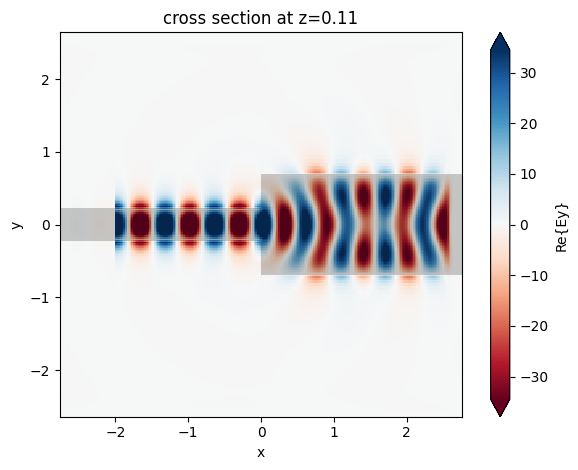

In [18]:
sim_data_jct.plot_field("field", "Ey", z=wg_height / 2, f=freq0, val="real")
plt.show()


This time, the output waveguide is multi-mode, and there is obviously some mode-mixing happening. We can use the mode monitor to exactly quantify this.

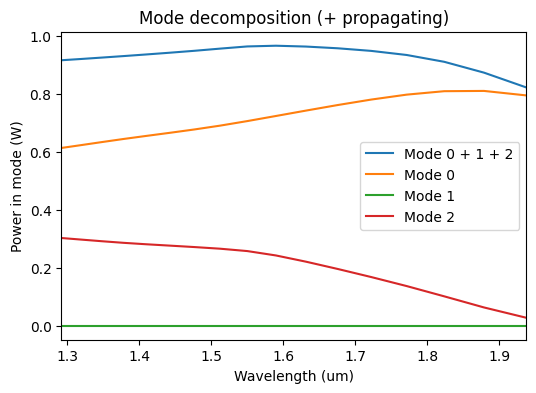

In [19]:
# Forward and backward power amplitude coefficients normalized to the straight waveguide flux
mode_amps_jct = sim_data_jct["mode"]
coeffs_f_jct = mode_amps_jct.amps.sel(direction="+") / np.sqrt(flux_wg.data[:, None])
coeffs_b_jct = mode_amps_jct.amps.sel(direction="-") / np.sqrt(flux_wg.data[:, None])

fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(lambdas, np.sum(np.abs(coeffs_f_jct.values) ** 2, axis=1))
ax.plot(lambdas, np.abs(coeffs_f_jct.values) ** 2)
ax.set_xlabel("Wavelength (um)")
ax.set_xlim([lambdas[-1], lambdas[0]])
ax.set_ylabel("Power in mode (W)")
ax.set_title("Mode decomposition (+ propagating)")
ax.legend(["Mode 0 + 1 + 2", "Mode 0", "Mode 1", "Mode 2"])
plt.show()


Because of the symmetry with respect to the $y=0$ plane, the power in Mode 0 cannot be converted to Mode 1, but a significant amount of power is converted to Mode 3. Note also that the combined power in the computed modes is smaller than 1W. The missing part is most likely lost in scattering at the sharp waveguide interface.

### Waveguide junction (using broadband source)

To demonstrate the broadband source capabilities more clearly we will re-run both the straight waveguide and waveguide junction cases. To create a broadband source one needs to specify the number of points, `num_freqs`, that will be used for approximating the frequency dependence. Note that these points will be arranged into a Chebyshev grid, thus a very fast convergence of polynomial approximation is expected and only few points are enough to reach converged results. Another important aspect is that these points are placed in the interval `(freq0 - 1.5 * fwidth, freq0 + 1.5 * fwidth)`, where `freq0` and `fwidth` are the source's parameters, and using broadband sources is not expected to significantly improve results outside of this interval. Use `freq0` and `fwidth` source parameters to adjust the frequency window where the best accuracy is desired.

In [20]:
broadband_mode_source = mode_source.copy(update={"num_freqs": 7})


Duplicate previously defined simulations and update the source lists.

In [21]:
sim_bb = sim.copy(update={"sources": [broadband_mode_source]})
sim_jct_bb = sim_jct.copy(update={"sources": [broadband_mode_source]})


First, let us re-run the straight waveguide case.

In [22]:
job = web.Job(simulation=sim_bb, task_name="mode_tutorial", verbose=True)
sim_data_bb = job.run(path="data/simulation_bb.hdf5")


04:39:15 PDT Created task 'mode_tutorial' with task_id                          
             'fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=587781;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=202896;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\taskId]8;;\]8;id=587781;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\=]8;;\]8;id=84781;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\fdve]8;;\]8;id=587781;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\-eed56695-4a0]8;;\
             ]8;id=587781;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\e-4b17-b1ea-d70d8733f8fe']8;;\.

Output()

04:39:16 PDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

04:39:35 PDT status = success

             View simulation result at                                          
             ]8;id=540199;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=95348;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\taskId]8;;\]8;id=540199;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\=]8;;\]8;id=581694;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\fdve]8;;\]8;id=540199;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\-eed56695-4a0]8;;\
             ]8;id=540199;https://tidy3d.simulation.cloud/workbench?taskId=fdve-eed56695-4a0e-4b17-b1ea-d70d8733f8fe\e-4b17-b1ea-d70d8733f8fe']8;;\.

Output()

04:39:36 PDT loading simulation from data/simulation_bb.hdf5

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

Plotting the total injected power and the power in injected mode one can see that a broadband source injects a chosen mode much more accurately throughout the target frequency range (`+/- 1.5 * fwidth`). That is, the total injected power is equal to 1 W at all frequencies and all of that power is concentrated in the chosen mode. Note that results degrade outside of the target range as expected.

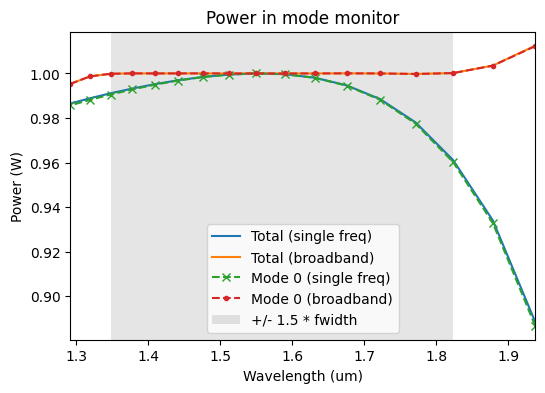

In [23]:
flux_wg_bb = sim_data_bb["flux"].flux

# Forward and backward power amplitude coefficients
mode_amps_bb = sim_data_bb["mode"]
coeffs_f_bb = mode_amps_bb.amps.sel(direction="+")
coeffs_b_bb = mode_amps_bb.amps.sel(direction="-")

fig, ax = plt.subplots(1, figsize=(6, 4))

ax.plot(lambdas, flux_wg)
ax.plot(lambdas, flux_wg_bb)

ax.plot(lambdas, np.abs(coeffs_f.sel(mode_index=0)) ** 2, "x--")
ax.plot(lambdas, np.abs(coeffs_f_bb.sel(mode_index=0)) ** 2, ".--")

ax.set_xlim([lambdas[-1], lambdas[0]])
ax.set_xlabel("Wavelength (um)")
ax.set_ylabel("Power (W)")
ax.set_title("Power in mode monitor")
ax.axvspan(
    td.C_0 / (freq0 + 1.5 * fwidth),
    td.C_0 / (freq0 - 1.5 * fwidth),
    facecolor="k",
    alpha=0.1,
)

ax.legend(
    [
        "Total (single freq)",
        "Total (broadband)",
        "Mode 0 (single freq)",
        "Mode 0 (broadband)",
        "+/- 1.5 * fwidth",
    ]
)

plt.show()


Let us re-run the waveguide junction example now and compare to previous results.

In [24]:
job = web.Job(simulation=sim_jct_bb, task_name="mode_tutorial", verbose=True)
sim_data_jct_bb = job.run(path="data/mode_converter_bb.hdf5")


             Created task 'mode_tutorial' with task_id                          
             'fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=739955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=653589;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\taskId]8;;\]8;id=739955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\=]8;;\]8;id=392445;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\fdve]8;;\]8;id=739955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\-907be8fb-fc2]8;;\
             ]8;id=739955;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\e-4bf7-a841-f0283ba67142']8;;\.

Output()

04:39:37 PDT status = queued

             To cancel the simulation, use 'web.abort(task_id)' or              
             'web.delete(task_id)' or abort/delete the task in the web UI.      
             Terminating the Python script will not stop the job running on the 
             cloud.

...

04:39:55 PDT status = success

             View simulation result at                                          
             ]8;id=303703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=407009;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\taskId]8;;\]8;id=303703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\=]8;;\]8;id=588588;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\fdve]8;;\]8;id=303703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\-907be8fb-fc2]8;;\
             ]8;id=303703;https://tidy3d.simulation.cloud/workbench?taskId=fdve-907be8fb-fc2e-4bf7-a841-f0283ba67142\e-4bf7-a841-f0283ba67142']8;;\.

Output()

04:40:01 PDT loading simulation from data/mode_converter_bb.hdf5

             WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

Here we plot the comparison for mode mixing results between three options: (1) the simulation containing a mode source that uses only one frequency point, (2) the same as first one, but normalized by flux derived from straight waveguide simulation, and (3) the simulation containing a broadband mode source that uses mutliple frequency points. As one can see, using the broadband source feature allows to obtain results of the same accuracy without running an additional normalization simulation.

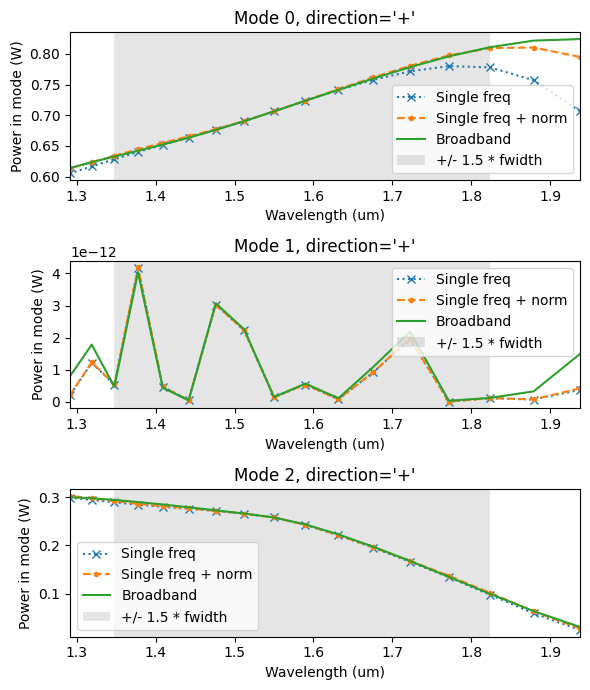

In [25]:
# Forward and backward power amplitude coefficients using broadband source
mode_amps_jct_bb = sim_data_jct_bb["mode"]
coeffs_f_jct_bb = mode_amps_jct_bb.amps.sel(direction="+")
coeffs_b_jct_bb = mode_amps_jct_bb.amps.sel(direction="-")

# Forward and backward power amplitude coefficients using single frequency source and without normalization
coeffs_f_jct_nonorm = mode_amps_jct.amps.sel(direction="+")
coeffs_b_jct_nonorm = mode_amps_jct.amps.sel(direction="-")

fig, ax = plt.subplots(3, 1, figsize=(6, 7), tight_layout=True)
for mode_index in range(3):
    ax[mode_index].plot(
        lambdas, np.abs(coeffs_f_jct_nonorm.sel(mode_index=mode_index)) ** 2, "x:"
    )
    ax[mode_index].plot(
        lambdas, np.abs(coeffs_f_jct.sel(mode_index=mode_index)) ** 2, ".--"
    )
    ax[mode_index].plot(
        lambdas, np.abs(coeffs_f_jct_bb.sel(mode_index=mode_index)) ** 2
    )
    ax[mode_index].set_xlabel("Wavelength (um)")
    ax[mode_index].set_xlim([lambdas[-1], lambdas[0]])
    ax[mode_index].set_ylabel("Power in mode (W)")
    ax[mode_index].set_title(f"Mode {mode_index}, direction='+'")
    ax[mode_index].axvspan(
        td.C_0 / (freq0 + 1.5 * fwidth),
        td.C_0 / (freq0 - 1.5 * fwidth),
        facecolor="k",
        alpha=0.1,
    )
    ax[mode_index].legend(
        ["Single freq", "Single freq + norm", "Broadband", "+/- 1.5 * fwidth"]
    )
plt.show()
